In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ujjwalchowdhury/energy-efficiency-data-set/energy_efficiency_data.csv


Importing enegy efficiency data frame

This project aims to predict the heating load of buildings based on their physical and architectural characteristics using a linear regression model.

In [17]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ujjwalchowdhury/energy-efficiency-data-set")
print("Path to dataset files:", path)
import os
print(path)
print(os.listdir(path))


file_path = os.path.join(path, "energy_efficiency_data.csv")
df = pd.read_csv(file_path)

print(df.head())

Path to dataset files: /kaggle/input/datasets/ujjwalchowdhury/energy-efficiency-data-set
/kaggle/input/datasets/ujjwalchowdhury/energy-efficiency-data-set
['energy_efficiency_data.csv']
   Relative_Compactness  Surface_Area  Wall_Area  Roof_Area  Overall_Height  \
0                  0.98         514.5      294.0     110.25             7.0   
1                  0.98         514.5      294.0     110.25             7.0   
2                  0.98         514.5      294.0     110.25             7.0   
3                  0.98         514.5      294.0     110.25             7.0   
4                  0.90         563.5      318.5     122.50             7.0   

   Orientation  Glazing_Area  Glazing_Area_Distribution  Heating_Load  \
0            2           0.0                          0         15.55   
1            3           0.0                          0         15.55   
2            4           0.0                          0         15.55   
3            5           0.0                   

The dataset contains features such as relative compactness, surface area, glazing area, and building height, along with target variables representing heating and cooling loads.

In [18]:
print(type(df))
print(df.shape)
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
(768, 10)
Index(['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area',
       'Overall_Height', 'Orientation', 'Glazing_Area',
       'Glazing_Area_Distribution', 'Heating_Load', 'Cooling_Load'],
      dtype='object')


The dataset was first explored to understand the relationships between the input features and the target variable (heating load). Summary statistics and correlation analysis were used to identify the most relevant variables.

In [19]:
df.describe()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307201,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090196,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


In [20]:
df.corr()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
Relative_Compactness,1.000000e+00,-9.919015e-01,-2.037817e-01,-8.688234e-01,8.277473e-01,4.678592e-17,-2.960552e-15,-7.107006e-16,0.622272,0.634339
Surface_Area,-9.919015e-01,1.000000e+00,1.955016e-01,8.807195e-01,-8.581477e-01,-3.459372e-17,3.636925e-15,2.438409e-15,-0.658120,-0.672999
Wall_Area,-2.037817e-01,1.955016e-01,1.000000e+00,-2.923165e-01,2.809757e-01,-2.429499e-17,-8.567455e-17,2.067384e-16,0.455671,0.427117
Roof_Area,-8.688234e-01,8.807195e-01,-2.923165e-01,1.000000e+00,-9.725122e-01,-5.830058e-17,-1.759011e-15,-1.078071e-15,-0.861828,-0.862547
Overall_Height,8.277473e-01,-8.581477e-01,2.809757e-01,-9.725122e-01,1.000000e+00,4.492205e-17,1.489134e-17,-2.920613e-17,0.889431,0.895785
Orientation,4.678592e-17,-3.459372e-17,-2.429499e-17,-5.830058e-17,4.492205e-17,1.000000e+00,-9.406007e-16,-2.549352e-16,-0.002587,0.014290
Glazing_Area,-2.960552e-15,3.636925e-15,-8.567455e-17,-1.759011e-15,1.489134e-17,-9.406007e-16,1.000000e+00,2.129642e-01,0.269841,0.207505
Glazing_Area_Distribution,-7.107006e-16,2.438409e-15,2.067384e-16,-1.078071e-15,-2.920613e-17,-2.549352e-16,2.129642e-01,1.000000e+00,0.087368,0.050525
Heating_Load,6.222722e-01,-6.581202e-01,4.556712e-01,-8.618283e-01,8.894307e-01,-2.586534e-03,2.698410e-01,8.736759e-02,1.000000,0.975862
Cooling_Load,6.343391e-01,-6.729989e-01,4.271170e-01,-8.625466e-01,8.957852e-01,1.428960e-02,2.075050e-01,5.052512e-02,0.975862,1.000000


The analysis showed that heating load is strongly correlated with cooling load. However, cooling load was excluded from the model to avoid data leakage.

In [21]:
df[["Overall_Height", "Heating_Load"]].head()

,Overall_Height,Heating_Load
0,7.0,15.55
1,7.0,15.55
2,7.0,15.55
3,7.0,15.55
4,7.0,20.84


In [22]:
df.corr()["Heating_Load"].sort_values(ascending=False)

Heating_Load                 1.000000
Cooling_Load                 0.975862
Overall_Height               0.889431
Relative_Compactness         0.622272
Wall_Area                    0.455671
Glazing_Area                 0.269841
Glazing_Area_Distribution    0.087368
Orientation                 -0.002587
Surface_Area                -0.658120
Roof_Area                   -0.861828
Name: Heating_Load, dtype: float64

We also see that relactive compactness correlates to the heating load

In [23]:
df[["Overall_Height", "Relative_Compactness"]].corr()

,Overall_Height,Relative_Compactness
Overall_Height,1.000000,0.827747
Relative_Compactness,0.827747,1.000000


Among the input features, overall height and relative compactness showed strong correlations with heating load. Additionally, these two features are highly correlated with each other (correlation ≈ 0.8), indicating redundancy in the dataset.

We start to implement the model. The model predicts the heating energy required for a building based on its physical characteristics such as relative compactness, surface area, height, and glazing properties. A linear regression model was trained to learn the relationship between building features and heating load

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X = df.drop(["Heating_Load", "Cooling_Load"], axis=1)
y = df["Heating_Load"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

mse = mean_squared_error(y_test, predictions)
print("MSE:", mse)

MSE: 9.153187855202754


The model achieved a mean squared error of approximately 9, corresponding to an average prediction error of about 3 units.

In [26]:
print(model.coef_)
print(X.columns)

[-6.18733542e+01 -6.01052714e-02  3.75534653e-02 -4.88293684e-02
  4.12366921e+00 -3.24391125e-02  2.01431925e+01  2.11102833e-01]
Index(['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area',
       'Overall_Height', 'Orientation', 'Glazing_Area',
       'Glazing_Area_Distribution'],
      dtype='object')


The analysis revealed several important insights about the relationship between building characteristics and heating load.
First, heating load is strongly correlated with cooling load, but this variable was excluded from the model to ensure a realistic prediction scenario.
Second, relative compactness and overall height are both strongly correlated with heating load and with each other. This indicates that these features contain overlapping information, which can lead to redundancy in the model.


In [27]:
for name, coef in zip(X.columns, model.coef_):
    print(name, coef)

Relative_Compactness -61.87335423897983
Surface_Area -0.060105271365024804
Wall_Area 0.03755346532191756
Roof_Area -0.04882936835137144
Overall_Height 4.123669206676684
Orientation -0.03243911252464677
Glazing_Area 20.143192483194806
Glazing_Area_Distribution 0.21110283343317549


Third, glazing area showed a strong influence in the regression model. However, removing this feature did not significantly affect model performance, suggesting that its effect can be partially captured by other variables.
Overall, the results highlight that multiple features contribute to predicting heating load, and that different combinations of variables can provide similar predictive performance.
What would happen if we remove this input?

In [28]:
X2 = X.drop(["Glazing_Area"], axis=1)

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X = df.drop(["Heating_Load", "Cooling_Load"], axis=1)
y = df["Heating_Load"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

mse = mean_squared_error(y_test, predictions)
print("MSE:", mse)

MSE: 9.153187855202754


Glazing area initially appeared as an important feature in the regression model. However, removing it did not significantly change the model’s performance, suggesting that its contribution is not unique and can be approximated by other correlated features. This highlights the presence of redundancy in the dataset.

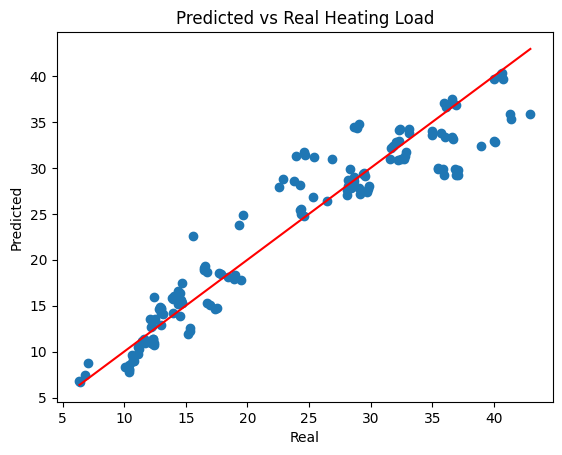

In [32]:
import matplotlib.pyplot as plt


plt.scatter(y_test, predictions)

# perfect line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Real")
plt.ylabel("Predicted")
plt.title("Predicted vs Real Heating Load")

plt.show()

This project demonstrates how machine learning can model the relationship between building design and energy demand. The results show that multiple features contribute redundantly to prediction, highlighting the importance of feature analysis